In [1]:
# Import packages
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
project_dir = Path("/home/mcaskey/10XvParse/")

import json
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import pandas as pd
from pybiomart import Server
from scipy.stats import pearsonr
import nb_utils

# Preprocess

In [2]:
kb_dir = project_dir / "Data/Analysis_2/parse/kb_python/all_out"
polyT_bcs_file = project_dir / "Configs/Analysis_2/parse/r1_T.txt"
rando_bcs_file = project_dir / "Configs/Analysis_2/parse/r1_R.txt"
replacement_bcs_file = project_dir / "Configs/Analysis_2/parse/replace.txt"
bc_to_wells_file = project_dir / "Configs/Analysis_2/parse/bcs_to_wells.txt"

In [3]:
# load data
parse_data = nb_utils.initProcessing('parse', kb_dir=kb_dir, data_title = "Parse", modified=True)
unmodified_data = nb_utils.initProcessing('parse', kb_dir=kb_dir, data_title = "Parse", modified=False)

In [4]:
# count in polyT and randO barcodes and extract the corresponding data from the unmodified data
with open(polyT_bcs_file, 'r') as f:
    polyT_bcs = [line.strip() for line in f]
with open(rando_bcs_file, 'r') as f:
    rando_bcs = [line.strip() for line in f]

polyT_data = unmodified_data[unmodified_data.obs_names.str.endswith(tuple(polyT_bcs))]
randO_data = unmodified_data[unmodified_data.obs_names.str.endswith(tuple(rando_bcs))]

# replace randO barcodes with polyT barcodes in randO data
with open(replacement_bcs_file, 'r') as f:
    for line in f:
        rando_bc, polyT_bc = line.strip().split()
        randO_data.obs_names = randO_data.obs_names.str.replace(f"{rando_bc}$", polyT_bc[1:], regex=True)

# Add well information to the data
bc_to_wells = {}
with open(bc_to_wells_file, 'r') as f:
    for line in f:
        bc, well = line.strip().split()
        bc_to_wells[bc] = well

randO_data.obs['well'] = randO_data.obs_names.str[-8:].map(bc_to_wells)
polyT_data.obs['well'] = polyT_data.obs_names.str[-8:].map(bc_to_wells)
parse_data.obs['well'] = parse_data.obs_names.str[-8:].map(bc_to_wells)

/tmp/ipykernel_3261048/2992652321.py:24: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  polyT_data.obs['well'] = polyT_data.obs_names.str[-8:].map(bc_to_wells)


In [5]:
# Add polyT and randO count counts to parse data
parse_data.obs['polyT_counts'] = 0
parse_data.obs.loc[polyT_data.obs_names, 'polyT_counts'] = polyT_data.obs['n_counts']

parse_data.obs['randO_counts'] = 0
parse_data.obs.loc[randO_data.obs_names, 'randO_counts'] = randO_data.obs['n_counts']

# Parse Well Analysis

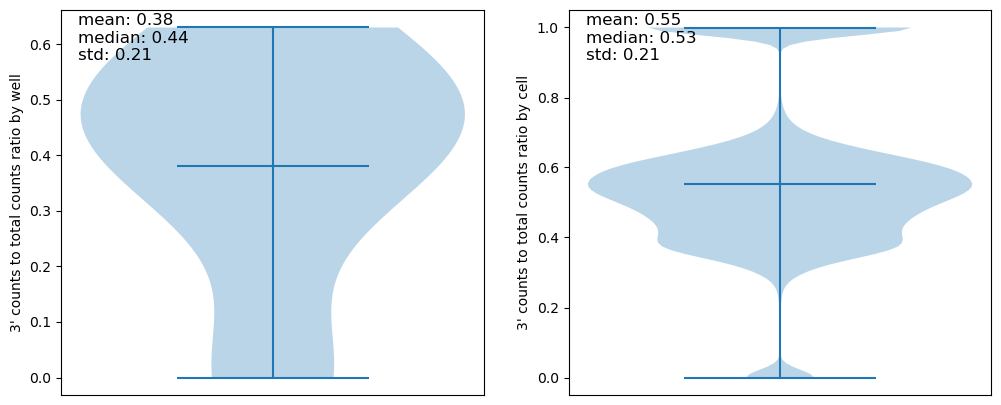

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

nb_utils.violinByWell(ax[0], parse_data.obs)
nb_utils.violinByCell(ax[1], parse_data.obs)

plt.show()

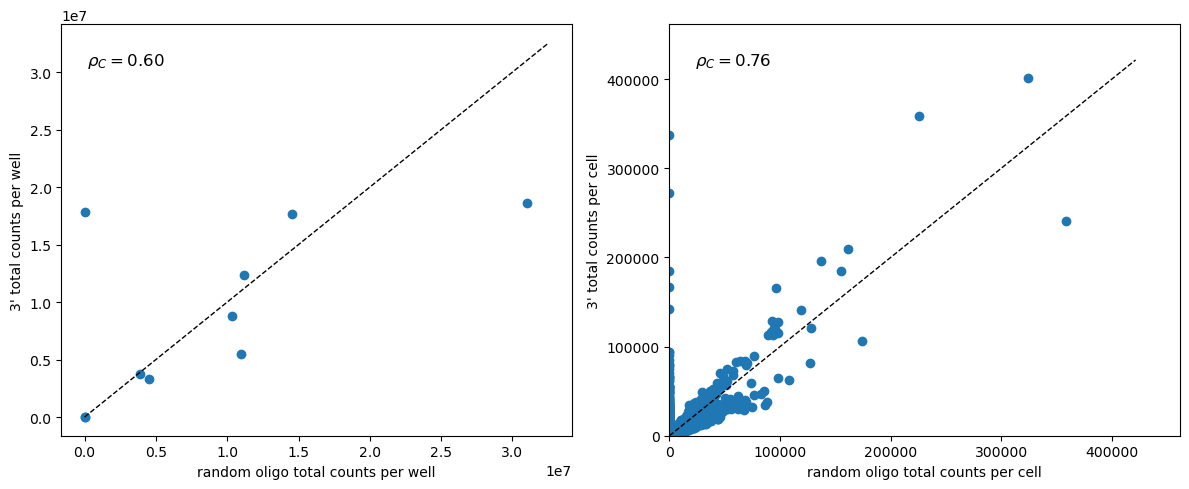

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

nb_utils.plotByWell(ax[0], parse_data.obs)
nb_utils.plotByCell(ax[1], parse_data.obs)

plt.tight_layout()
plt.show()

28,857 cells passed the 500 UMI threshold for Parse


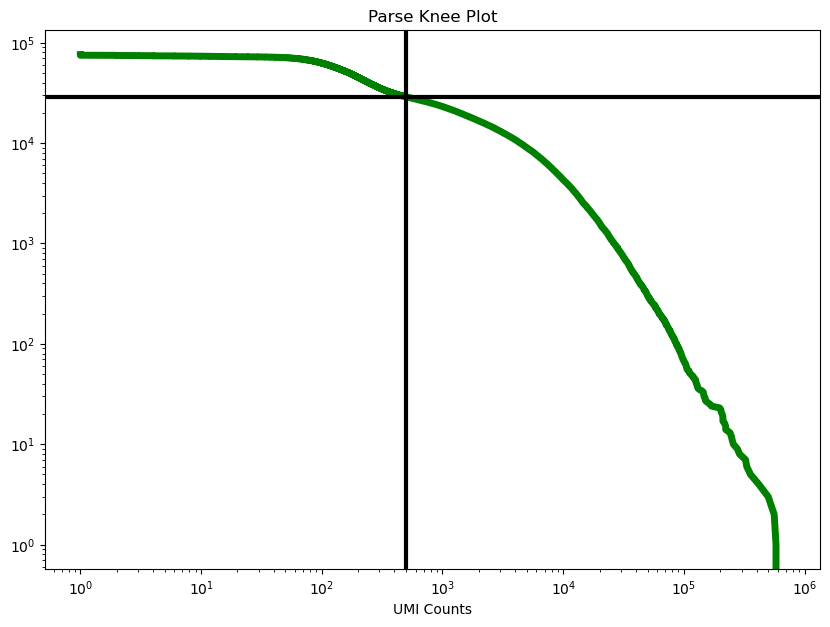

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

parse_filtered = nb_utils.knee_plot(ax, parse_data, cutoff = 500)
plt.show()

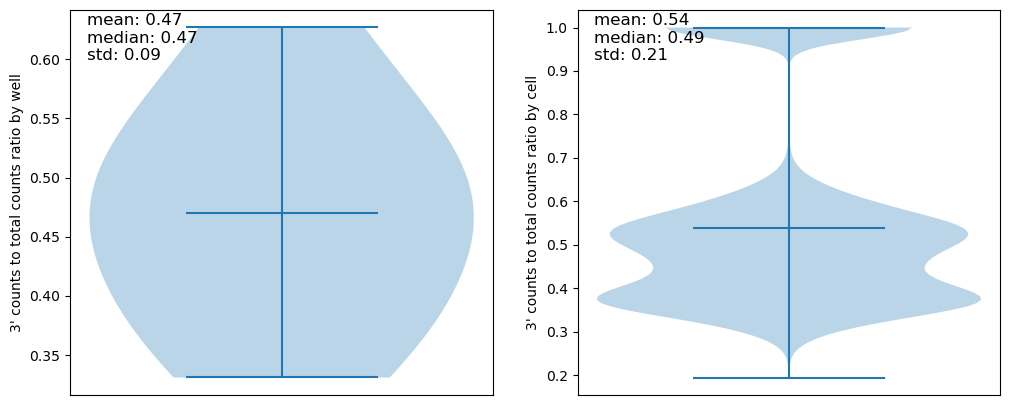

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

nb_utils.violinByWell(ax[0], parse_filtered.obs)
nb_utils.violinByCell(ax[1], parse_filtered.obs)

plt.show()

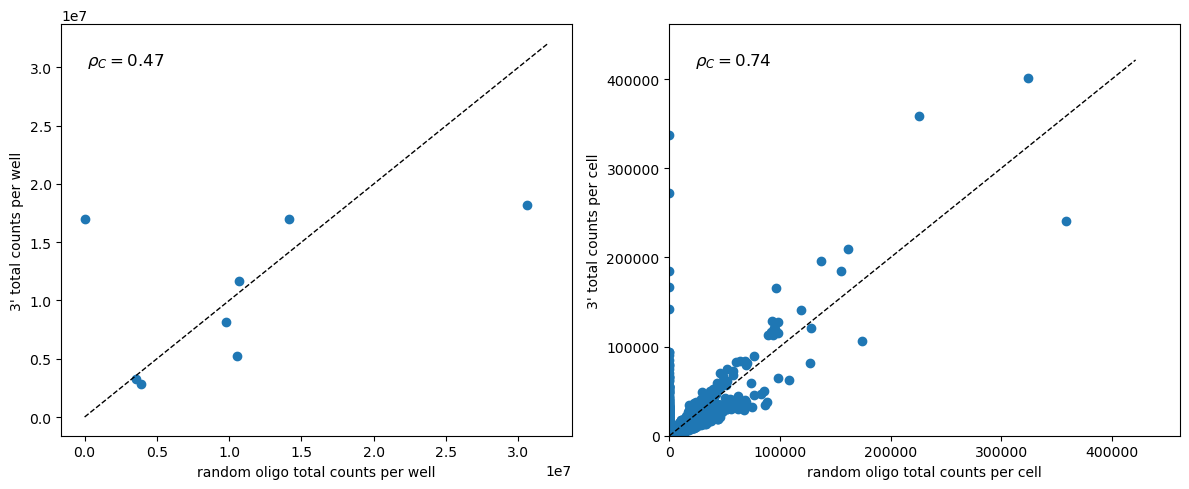

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

nb_utils.plotByWell(ax[0], parse_filtered.obs)
nb_utils.plotByCell(ax[1], parse_filtered.obs)

plt.tight_layout()
plt.show()